In [1]:
import pandas as pd
import numpy as np

# Load datasets
fear_greed = pd.read_csv("Data/fear_greed_index.csv")
trades = pd.read_csv("Data/historical_data.csv")

print("Fear Greed Shape:", fear_greed.shape)
print("Trades Shape:", trades.shape)
print("\nFear & Greed Index Preview:")
display(fear_greed.head())
print("\nTrades Dataset Preview:")
display(trades.head())

Fear Greed Shape: (2644, 4)
Trades Shape: (211224, 16)

Fear & Greed Index Preview:


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05



Trades Dataset Preview:


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [2]:
# Convert Timestamp IST to datetime with correct format
# Using dayfirst=True to handle DD-MM-YYYY format
trades['Timestamp IST'] = pd.to_datetime(trades['Timestamp IST'], dayfirst=True)

# Extract only date
trades['date'] = trades['Timestamp IST'].dt.date

# Check
trades[['Timestamp IST', 'date']].head()

,Timestamp IST,date
0,2024-12-02 22:50:00,2024-12-02
1,2024-12-02 22:50:00,2024-12-02
2,2024-12-02 22:50:00,2024-12-02
3,2024-12-02 22:50:00,2024-12-02
4,2024-12-02 22:50:00,2024-12-02


In [3]:
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02


In [4]:
# Convert Timestamp IST safely
trades['Timestamp IST'] = pd.to_datetime(trades['Timestamp IST'], errors='coerce')

# Drop rows where conversion failed
trades = trades.dropna(subset=['Timestamp IST'])

# Extract only date
trades['date'] = trades['Timestamp IST'].dt.date

# Check result
trades[['Timestamp IST', 'date']].head()

,Timestamp IST,date
0,2024-12-02 22:50:00,2024-12-02
1,2024-12-02 22:50:00,2024-12-02
2,2024-12-02 22:50:00,2024-12-02
3,2024-12-02 22:50:00,2024-12-02
4,2024-12-02 22:50:00,2024-12-02


In [5]:
fear_greed.dtypes

timestamp         int64
value             int64
classification      str
date                str
dtype: object

In [6]:
# Convert sentiment date to datetime
fear_greed['date'] = pd.to_datetime(fear_greed['date'])

# Extract only date (to match trades format)
fear_greed['date'] = fear_greed['date'].dt.date

# Check
fear_greed[['date', 'classification']].head()

,date,classification
0,2018-02-01,Fear
1,2018-02-02,Extreme Fear
2,2018-02-03,Fear
3,2018-02-04,Extreme Fear
4,2018-02-05,Extreme Fear


In [7]:
# Merge trades with sentiment on date
merged = pd.merge(
    trades,
    fear_greed[['date', 'classification']],
    on='date',
    how='left'
)

print("Merged Shape:", merged.shape)
merged[['date', 'classification']].head()

Merged Shape: (211224, 18)


,date,classification
0,2024-12-02,Extreme Greed
1,2024-12-02,Extreme Greed
2,2024-12-02,Extreme Greed
3,2024-12-02,Extreme Greed
4,2024-12-02,Extreme Greed


In [8]:
# Average PnL by sentiment
merged.groupby('classification')['Closed PnL'].mean()

classification
Extreme Fear     34.537862
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Neutral          34.307718
Name: Closed PnL, dtype: float64

In [9]:
merged.groupby('classification')['Size USD'].mean()

classification
Extreme Fear     5349.731843
Extreme Greed    3112.251565
Fear             7816.109931
Greed            5736.884375
Neutral          4782.732661
Name: Size USD, dtype: float64

In [10]:
# Create win flag
merged['win'] = merged['Closed PnL'] > 0

# Win rate by sentiment
merged.groupby('classification')['win'].mean()

classification
Extreme Fear     0.370607
Extreme Greed    0.464943
Fear             0.420768
Greed            0.384828
Neutral          0.396991
Name: win, dtype: float64

In [11]:
# Number of trades by sentiment
merged.groupby('classification').size()

classification
Extreme Fear     21400
Extreme Greed    39992
Fear             61837
Greed            50303
Neutral          37686
dtype: int64

In [12]:
# Count trades per day per sentiment
trades_per_day = merged.groupby(['date', 'classification']).size().reset_index(name='trade_count')

# Average daily trades per sentiment
trades_per_day.groupby('classification')['trade_count'].mean()

classification
Extreme Fear     1528.571429
Extreme Greed     350.807018
Fear              679.527473
Greed             260.637306
Neutral           562.477612
Name: trade_count, dtype: float64

In [13]:
trades.columns

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp', 'date'],
      dtype='str')

In [14]:
# Count total trades per account
trades_per_account = merged.groupby('Account').size().reset_index(name='total_trades')

trades_per_account.head()

,Account,total_trades
0,0x083384f897ee0f19899168e3b1bec365f52a9012,3818
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,7280
2,0x271b280974205ca63b716753467d5a371de622ab,3809
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,13311
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3239


In [15]:
median_trades = trades_per_account['total_trades'].median()

trades_per_account['segment'] = trades_per_account['total_trades'].apply(
    lambda x: 'High Frequency' if x >= median_trades else 'Low Frequency'
)

trades_per_account.head()

,Account,total_trades,segment
0,0x083384f897ee0f19899168e3b1bec365f52a9012,3818,High Frequency
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,7280,High Frequency
2,0x271b280974205ca63b716753467d5a371de622ab,3809,High Frequency
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,13311,High Frequency
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3239,Low Frequency


In [16]:
# Merge frequency segment back to merged dataset
merged = merged.merge(
    trades_per_account[['Account', 'segment']],
    on='Account',
    how='left'
)

merged[['Account', 'segment']].head()

,Account,segment
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,Low Frequency
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,Low Frequency
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,Low Frequency
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,Low Frequency
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,Low Frequency


In [17]:
merged.groupby('segment')['Closed PnL'].mean()

segment
High Frequency    42.493421
Low Frequency     96.943024
Name: Closed PnL, dtype: float64

In [18]:
merged['win'] = merged['Closed PnL'] > 0

merged.groupby('segment')['win'].mean()

segment
High Frequency    0.415438
Low Frequency     0.379116
Name: win, dtype: float64

In [19]:
# Daily PnL per account
daily_pnl = merged.groupby(['Account', 'date'])['Closed PnL'].sum().reset_index()

daily_pnl.head()

,Account,date,Closed PnL
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.0
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.0
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.0
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,-21227.0
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,1603.1


In [20]:
# Volatility (std deviation) of daily PnL per trader
pnl_volatility = daily_pnl.groupby('Account')['Closed PnL'].std().reset_index()

pnl_volatility.rename(columns={'Closed PnL': 'pnl_std'}, inplace=True)

pnl_volatility.head()

,Account,pnl_std
0,0x083384f897ee0f19899168e3b1bec365f52a9012,150401.797346
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,3603.042291
2,0x271b280974205ca63b716753467d5a371de622ab,33420.410014
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,2993.284702
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,4867.743469


In [21]:
# Find median volatility
median_vol = pnl_volatility['pnl_std'].median()

# Create consistency segment
pnl_volatility['consistency_segment'] = pnl_volatility['pnl_std'].apply(
    lambda x: 'Consistent' if x <= median_vol else 'Inconsistent'
)

pnl_volatility.head()

,Account,pnl_std,consistency_segment
0,0x083384f897ee0f19899168e3b1bec365f52a9012,150401.797346,Inconsistent
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,3603.042291,Consistent
2,0x271b280974205ca63b716753467d5a371de622ab,33420.410014,Inconsistent
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,2993.284702,Consistent
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,4867.743469,Consistent


In [22]:
merged = merged.merge(
    pnl_volatility[['Account', 'consistency_segment']],
    on='Account',
    how='left'
)

merged[['Account', 'consistency_segment']].head()

,Account,consistency_segment
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,Consistent
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,Consistent
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,Consistent
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,Consistent
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,Consistent


In [23]:
merged.groupby('consistency_segment')['Closed PnL'].mean()

consistency_segment
Consistent      19.015616
Inconsistent    69.791388
Name: Closed PnL, dtype: float64

In [24]:
merged.groupby('consistency_segment')['win'].mean()

consistency_segment
Consistent      0.419981
Inconsistent    0.405097
Name: win, dtype: float64

In [25]:
merged.groupby(['segment', 'classification'])['Closed PnL'].mean()

segment         classification
High Frequency  Extreme Fear       34.163353
                Extreme Greed      62.870911
                Fear               51.323784
                Greed              25.004641
                Neutral            34.579701
Low Frequency   Extreme Fear       35.941979
                Extreme Greed     103.264685
                Fear               80.835791
                Greed             210.210287
                Neutral            31.845656
Name: Closed PnL, dtype: float64

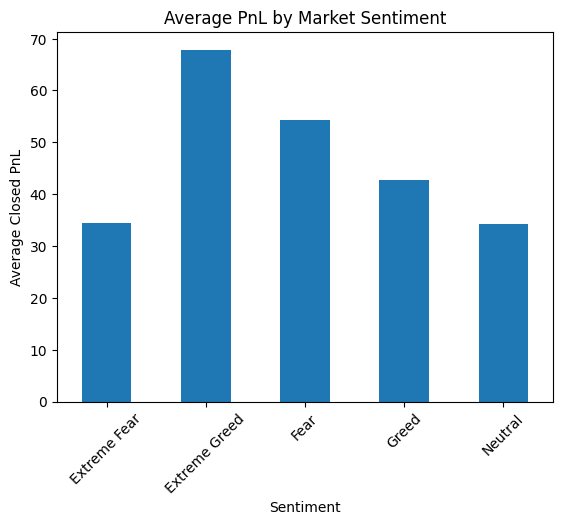

In [26]:
import matplotlib.pyplot as plt

# Average PnL by sentiment
sentiment_pnl = merged.groupby('classification')['Closed PnL'].mean()

plt.figure()
sentiment_pnl.plot(kind='bar')
plt.title('Average PnL by Market Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Average Closed PnL')
plt.xticks(rotation=45)
plt.show()

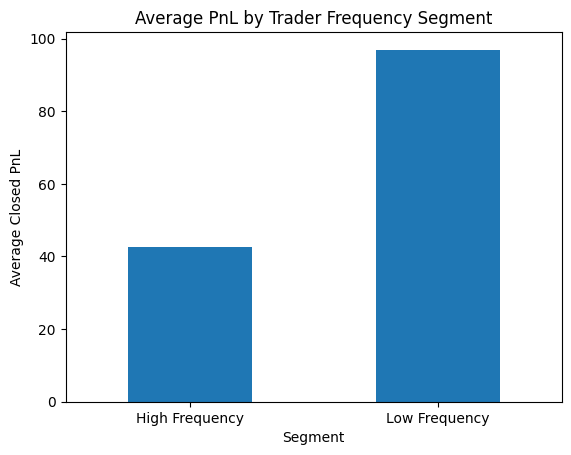

In [27]:
segment_pnl = merged.groupby('segment')['Closed PnL'].mean()

plt.figure()
segment_pnl.plot(kind='bar')
plt.title('Average PnL by Trader Frequency Segment')
plt.xlabel('Segment')
plt.ylabel('Average Closed PnL')
plt.xticks(rotation=0)
plt.show()

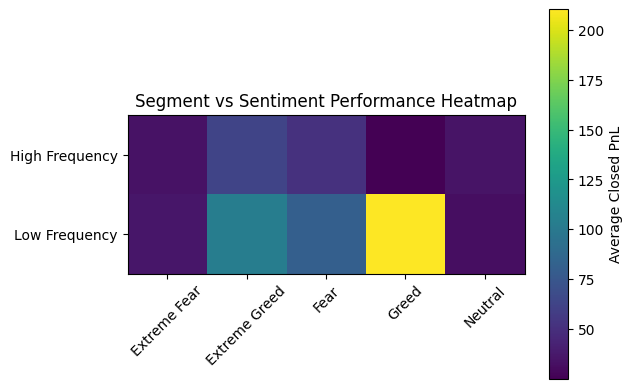

In [28]:
import pandas as pd

heatmap_data = merged.groupby(['segment', 'classification'])['Closed PnL'].mean().unstack()

plt.figure()
plt.imshow(heatmap_data)
plt.xticks(range(len(heatmap_data.columns)), heatmap_data.columns, rotation=45)
plt.yticks(range(len(heatmap_data.index)), heatmap_data.index)
plt.colorbar(label='Average Closed PnL')
plt.title('Segment vs Sentiment Performance Heatmap')
plt.show()

In [29]:
# Missing values
print("Missing values:\n", trades.isnull().sum())

# Duplicate rows
print("Duplicate rows:", trades.duplicated().sum())

Missing values:
 Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
date                0
dtype: int64
Duplicate rows: 0
